In [ ]:
from PIL import Image, ImageFilter, ImageStat
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2, glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy
import scipy.misc
import imageio
from skimage.transform import resize
from skimage import data
import PIL
import os
import itertools
from sklearn import model_selection
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score, StratifiedKFold
import sklearn
from sklearn.metrics import confusion_matrix
from keras import backend as K
from keras.layers import Conv2D, MaxPooling2D
import keras
from keras.models import Sequential, model_from_json
from keras.optimizers import SGD, RMSprop, Adam, Adagrad, Adadelta
from keras.layers import Dense, Activation, Dropout
from keras.utils.np_utils import to_categorical # convert to one-hot-encoding
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, MaxPooling2D, Activation
from keras.optimizers import RMSprop, SGD, Adam
from keras.preprocessing.image import ImageDataGenerator
from keras import callbacks
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, Callback, EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from keras import backend as K
%matplotlib inline
os.chdir('/kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset')

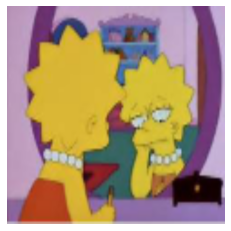

In [ ]:
# Plot Image
image_name = r"C:\Coding\Project\K\.agents\skills\frontend\kaggle_simpson_testset\lisa_simpson_18.jpg"
def plotLisa(image_location):
    image = cv2.imread(image_name)
    image = cv2.resize(image, (512,512))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.axis('off')
    return
plotLisa(image_name)

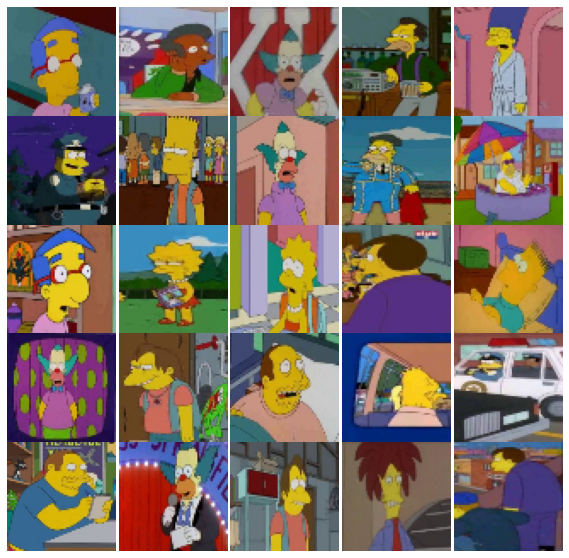

In [ ]:
# Plot Multiple Images
simpsons = glob.glob(r"C:\Coding\Project\K\.agents\skills\frontend\kaggle_simpson_testset\**")
i_ = 0
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
for l in simpsons[:25]:
    im = cv2.imread(l)
    im = cv2.resize(im, (64, 64)) 
    plt.subplot(5, 5, i_+1) #.set_title(l)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis('off')
    i_ += 1

In [ ]:
map_characters = {0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson', 
        3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel', 
        7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lenny_leonard', 11:'lisa_simpson',
        12: 'marge_simpson', 13: 'mayor_quimby',14:'milhouse_van_houten', 15: 'moe_szyslak', 
        16: 'ned_flanders', 17: 'nelson_muntz', 18: 'principal_skinner', 19: 'sideshow_bob'}

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (10,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
img_size = 64
# Load and Compress/Resize Test Data
dict_characters = {0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'moe_szyslak', 
        3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel', 
        7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lenny_leonard', 11:'lisa_simpson',
        12: 'marge_simpson', 13: 'mayor_quimby',14:'milhouse_van_houten', 15: 'bart_simpson', 
        16: 'ned_flanders', 17: 'nelson_muntz', 18: 'principal_skinner', 19: 'sideshow_bob'}

In [ ]:
def load_test_set(dirname,dict_characters):
    X_test = []
    Y_test = []
    for image_name in os.listdir(dirname):
        character_name = "_".join(image_name.split('_')[:-1])
        label = [label for label,character in dict_characters.items() if character == character_name][0]
        image = imageio.imread(dirname+'/'+image_name)
        X_test.append(resize(image,(img_size,img_size)))
        Y_test.append(label)
    return np.array(X_test), np.array(Y_test)
X_test, Y_test = load_test_set("/kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset", dict_characters)

In [ ]:
from os import listdir
directory_name = "/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset/simpsons_dataset"

In [ ]:
def load_train_set(dirname,dict_characters):
   X_train = []
   Y_train = []
   for label,character in dict_characters.items():
       list_images = os.listdir(dirname+'/'+character)
       for image_name in list_images[0:150]:
           image = imageio.imread(dirname+'/'+character+'/'+image_name)
           X_train.append(resize(image,(img_size,img_size)))
           Y_train.append(label)
   return np.array(X_train), np.array(Y_train)
X_train, Y_train = load_train_set("/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset/simpsons_dataset", dict_characters)    

In [ ]:
# Split data for cross validation
X_test, Y_test = load_test_set("/kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset", dict_characters) 
X_train, Y_train = load_train_set("/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset/simpsons_dataset", dict_characters)       
# Reduce Sample Size for DeBugging 
X_train = X_train[0:3000] 
Y_train = Y_train[0:3000]
X_test = X_test[0:1000] 
Y_test = Y_test[0:1000]
print("Training Data Shape:", X_train.shape, X_train.shape)
print("Testing Data Shape:", X_test.shape, X_test.shape)
# Encode labels to hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
Y_train = to_categorical(Y_train, num_classes = 20)
Y_test = to_categorical(Y_test, num_classes = 20)

Training Data Shape: (3000, 64, 64, 3) (3000, 64, 64, 3)
Testing Data Shape: (990, 64, 64, 3) (990, 64, 64, 3)


In [ ]:
def createModel():
    batch_size = 128
    num_classes = 20
    epochs = 60
    img_rows, img_cols = X_train.shape[1],X_train.shape[2]
    input_shape = (img_rows, img_cols, 3)
    model = Sequential()
    model.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu', input_shape = input_shape))
    model.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu'))
    model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(Conv2D(filters = 86, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu'))
    model.add(Conv2D(filters = 86, kernel_size = (3,3),padding = 'Same', 
                     activation ='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1024, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(512, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(20, activation = "softmax"))
    # Define the optimizer
    optimizer = RMSprop(lr=0.001, decay=1e-6)
    model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])
    print(model.summary())
    return model

In [ ]:
def fitModel(a,b,model):
    
    epochs = 60
    img_rows, img_cols = X_train.shape[1],X_train.shape[2]
    input_shape = (img_rows, img_cols, 3)
    
    datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images
    datagen.fit(a)
    model.fit_generator(datagen.flow(a,b, batch_size=32),
                        steps_per_epoch=len(a) / 32, epochs=epochs)
    return model
    

In [ ]:
def evaluateModel(model, c,d):
    score = model.evaluate(c,d, verbose=0)
    print('\nKeras CNN #2B - accuracy:', score[1])
    print('')
    y_pred = model.predict(c)
    print('\n', sklearn.metrics.classification_report(np.where(d > 0)[1], np.argmax(y_pred, axis=1), target_names=list(map_characters.values())), sep='')    
    Y_pred_classes = np.argmax(y_pred,axis = 1) 
    Y_true = np.argmax(d,axis = 1) 
    confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
    plot_confusion_matrix(confusion_mtx, classes = list(dict_characters.values())) 


In [ ]:
model = createModel()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 32)        896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 32, 32, 32)        0         
_________________________________________________________________
batch_normalization (BatchNo (None, 32, 32, 32)        128       
_________________________________________________________________
dropout (Dropout)            (None, 32, 32, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 32, 32, 64)        3

In [ ]:
model = fitModel(X_train, Y_train, model)

Epoch 1/60
94/93 [==============================] - 4s 37ms/step - loss: 3.6408 - accuracy: 0.0873
Epoch 2/60
94/93 [==============================] - 4s 41ms/step - loss: 3.0268 - accuracy: 0.1343
Epoch 3/60
94/93 [==============================] - 3s 37ms/step - loss: 2.7949 - accuracy: 0.2027
Epoch 4/60
94/93 [==============================] - 3s 37ms/step - loss: 2.5947 - accuracy: 0.2650
Epoch 5/60
94/93 [==============================] - 4s 41ms/step - loss: 2.3882 - accuracy: 0.3127
Epoch 6/60
94/93 [==============================] - 3s 37ms/step - loss: 2.2724 - accuracy: 0.3477
Epoch 7/60
94/93 [==============================] - 4s 42ms/step - loss: 2.1248 - accuracy: 0.3853
Epoch 8/60
94/93 [==============================] - 4s 40ms/step - loss: 1.9849 - accuracy: 0.4240
Epoch 9/60
94/93 [==============================] - 4s 37ms/step - loss: 1.8766 - accuracy: 0.4600
Epoch 10/60
94/93 [==============================] - 4s 37ms/step - loss: 1.8694 - accuracy: 0.4637
Epoch 11/


Keras CNN #2B - accuracy: 0.7434343695640564


                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.91      0.60      0.72        48
  apu_nahasapeemapetilon       0.94      0.88      0.91        50
            bart_simpson       0.60      0.70      0.65        50
charles_montgomery_burns       0.77      0.50      0.61        48
            chief_wiggum       0.93      0.82      0.87        50
          comic_book_guy       1.00      0.53      0.69        49
          edna_krabappel       0.78      0.90      0.83        50
           homer_simpson       0.39      0.60      0.47        50
           kent_brockman       0.93      0.82      0.87        50
        krusty_the_clown       1.00      0.72      0.84        50
           lenny_leonard       0.87      0.82      0.85        50
            lisa_simpson       0.62      0.30      0.41        50
           marge_simpson       0.87      0.90      0.88        50
            mayor_quimby   

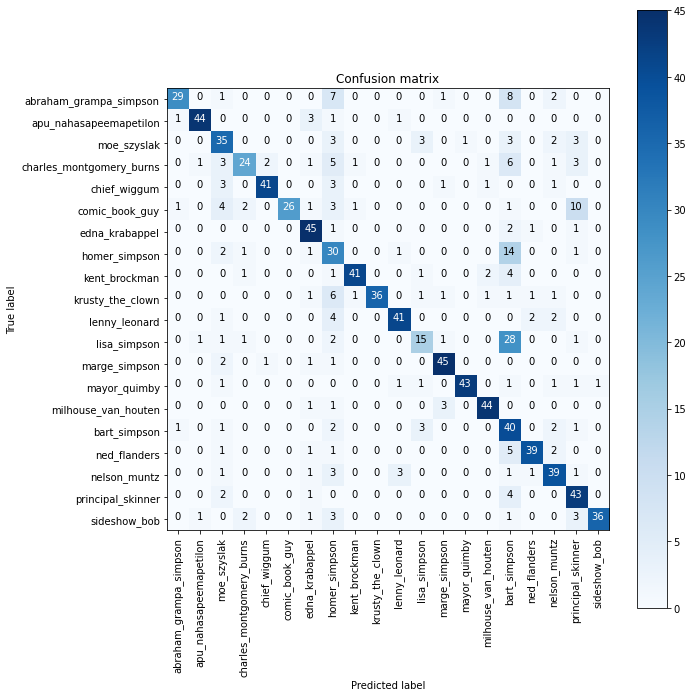

In [ ]:
evaluateModel(model, X_test, Y_test)

In [ ]:
def predict(filename):
    img_rows, img_cols = X_train.shape[1],X_train.shape[2]
    image=cv2.imread (filename)
    img=image/255 # rescale the image
    #print(img.shape)
    img=cv2.resize(img, (img_rows, img_cols)) # resize to same size used in training
    #print (img.shape)
    img=np.expand_dims(img, axis=0)
    pred=model.predict_classes(img)
    print(dict_characters[pred[0]])
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.axis('off')

In [ ]:
dict_characters = {0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson', 
        3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel', 
        7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lenny_leonard', 11:'lisa_simpson',
        12: 'marge_simpson', 13: 'mayor_quimby',14:'milhouse_van_houten', 15: 'moe_szyslak', 
        16: 'ned_flanders', 17: 'nelson_muntz', 18: 'principal_skinner', 19: 'sideshow_bob'}

edna_krabappel


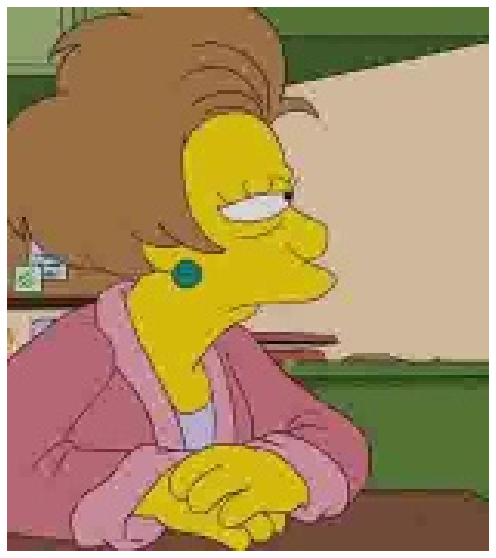

In [ ]:
fp1 = '/kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset/edna_krabappel_49.jpg'
predict(fp1)

principal_skinner


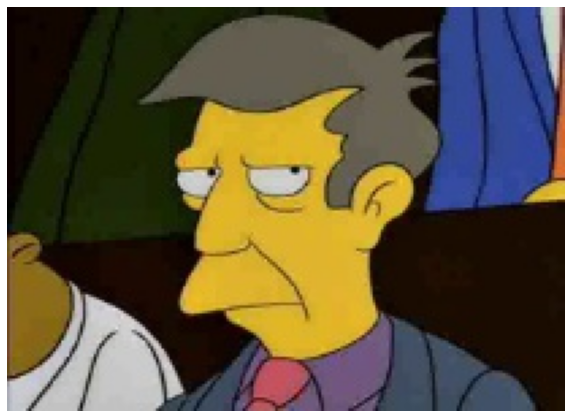

In [ ]:
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

def compute_saliency_map(model, filename, dict_characters, img_rows=64, img_cols=64):
    # Same preprocessing as predict()
    image = cv2.imread(filename)
    img = image / 255.0
    img = cv2.resize(img, (img_rows, img_cols))
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)

    # Predict class
    preds = model.predict(img_batch)
    pred_class = int(np.argmax(preds[0]))
    pred_label = dict_characters[pred_class]
    print("Predicted character:", pred_label)

    # Vanilla gradient saliency map via tf-keras-vis
    score = CategoricalScore([pred_class])
    saliency = Saliency(model, model_modifier=ReplaceToLinear(), clone=True)
    saliency_map = saliency(score, img_batch)[0]

    return saliency_map, pred_label

In [ ]:
saliency_map, pred_label = compute_saliency_map(model, fp1, dict_characters)

plt.imshow(saliency_map, cmap='hot')
plt.title(f"Saliency Map ({pred_label})")
plt.axis('off')
plt.show()